# Atividade Prática — Aula 5: Visualização de Dados para Decisões com Matplotlib e Seaborn

Esta atividade foi construída com base nos slides da Aula 5, cujo foco é transformar dados limpos em **gráficos que apoiem decisões**, e não em imagens decorativas. A aula reforça que o bom gráfico reduz esforço cognitivo, responde uma pergunta de negócio e precisa ser claro, comparável, simples e honesto. fileciteturn6file0

## Regras desta atividade
- Você deve **construir os códigos**.
- O notebook orienta os passos, mas não entrega a solução pronta.
- Após cada gráfico principal, escreva uma **interpretação curta** em markdown.
- O gráfico deve ser tratado como parte do seu portfólio: título, unidade, ordenação e mensagem importam. fileciteturn6file0

## Dataset da atividade
Arquivo: `vendas_brasil_clean_aula5.csv`


## 1. Preparação do ambiente

Importe as bibliotecas necessárias para trabalhar com:
- manipulação de dados
- gráficos com Matplotlib
- gráficos com Seaborn

**Sugestão:**
- `pandas`
- `matplotlib.pyplot`
- `seaborn`


In [1]:
# Escreva aqui suas importações
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Leitura da base

Leia o arquivo `vendas_brasil_clean_aula5.csv` em um DataFrame chamado `df`.

Depois:
1. exiba as primeiras linhas
2. verifique o tamanho da base
3. confira os tipos das colunas
4. observe quais variáveis podem ser usadas para:
   - comparação
   - tendência
   - distribuição
   - relação entre métricas


In [4]:
# Leia o CSV e faça uma inspeção inicial
df = pd.read_csv('vendas_brasil_clean_aula5.csv')

# 1. Primeiras linhas
print(df.head())

# 2. Tamanho da base
print(df.shape)

# 3. Tipos das colunas
print(df.dtypes)

         data  uf  canal_venda     segmento   categoria         produto  \
0  2024-03-17  SC  Marketplace       Varejo  Acessórios     Mouse Gamer   
1  2024-08-28  BA       Online       Varejo  Acessórios     Mouse Gamer   
2  2024-11-08  RJ  Marketplace  Corporativo      Móveis  Cadeira Office   
3  2024-08-21  RJ       Online       Varejo  Acessórios     Headset Pro   
4  2024-03-14  RJ   Televendas  Corporativo  Acessórios     Headset Pro   

   quantidade  preco_unitario  receita      lucro  margem_lucro      mes  
0           3          221.45   664.35  -110.6595     -0.166568  2024-03  
1           3          195.52   586.56   232.5600      0.396500  2024-08  
2           9         1079.28  9713.52  3416.6700      0.351700  2024-11  
3           3          309.43   928.29   416.8800      0.449100  2024-08  
4           6          313.42  1880.52   778.5600      0.414000  2024-03  
(480, 12)
data               object
uf                 object
canal_venda        object
segmento   

# 4. Variáveis úteis:
# - comparação: canal_venda, categoria, segmento, uf
# - tendência: mes, data_venda
# - distribuição: margem_lucro, receita
# - relação entre métricas: receita x lucro


In [3]:
from google.colab import files
uploaded = files.upload()

Saving vendas_brasil_clean_aula5.csv to vendas_brasil_clean_aula5.csv


## 3. Traduzindo a pergunta em gráfico

A aula destaca que a escolha do gráfico nunca é aleatória: a pergunta define a visualização. fileciteturn6file0

### Tarefa
Preencha em markdown pelo menos 4 exemplos no formato:

- **Pergunta do gestor:** ...
- **Variáveis (Pandas):** ...
- **Tipo de gráfico:** ...
- **Biblioteca sugerida:** ...

Use como referência a matriz mostrada nos slides:
- evolução no tempo → linha
- ranking/comparação entre grupos → barras
- variabilidade e outliers → boxplot
- correlação entre duas métricas → scatter


**Exemplo 1**
- Pergunta do gestor: Qual canal gera mais receita?
- Variáveis (Pandas): canal_venda, receita
- Tipo de gráfico: Barras horizontais
- Biblioteca sugerida: Matplotlib

**Exemplo 2**
- Pergunta do gestor: A receita cresce ao longo dos meses?
- Variáveis (Pandas): mes, receita
- Tipo de gráfico: Linha
- Biblioteca sugerida: Matplotlib

**Exemplo 3**
- Pergunta do gestor: A margem oscila muito por segmento?
- Variáveis (Pandas): segmento, margem_lucro
- Tipo de gráfico: Boxplot
- Biblioteca sugerida: Seaborn

**Exemplo 4**
- Pergunta do gestor: Produto que fatura muito também dá lucro?
- Variáveis (Pandas): receita, lucro
- Tipo de gráfico: Scatter plot
- Biblioteca sugerida: Matplotlib ou Seaborn


## 4. Gráfico de barras horizontais — Qual canal gera mais caixa?

A missão prática do slide pede responder: **qual canal gera mais caixa?** fileciteturn6file0

### Tarefa
1. Agrupe a receita por `canal_venda`
2. Ordene os valores
3. Gere um gráfico de **barras horizontais**
4. Use rótulos e título claros
5. Certifique-se de que a visualização esteja limpa e fácil de ler

### Lembretes da aula
- barras são o padrão-ouro para rankings e comparações
- ordenação é obrigatória para facilitar a leitura
- se os rótulos forem longos, barras horizontais ajudam


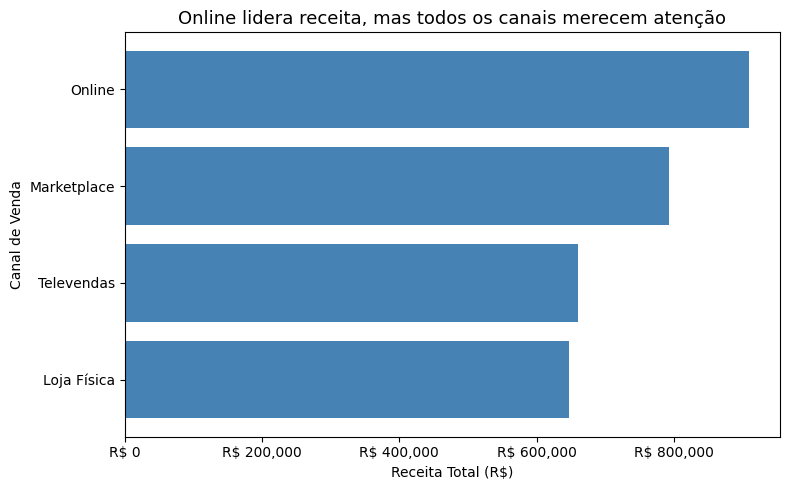

In [5]:
canal_receita = df.groupby('canal_venda')['receita'].sum().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(canal_receita.index, canal_receita.values, color='steelblue')

ax.set_title('Online lidera receita, mas todos os canais merecem atenção', fontsize=13)
ax.set_xlabel('Receita Total (R$)')
ax.set_ylabel('Canal de Venda')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))

plt.tight_layout()
plt.show()


O canal Online concentra a maior parte da receita, enquanto o canal Loja Física
fica atrás em volume. Para o gestor, a decisão seria investir em marketing digital
para ampliar o canal líder ou revisar a estratégia do canal com menor desempenho.




## 5. Gráfico de linha — Como é a sazonalidade ao longo dos meses?

Os slides destacam que linhas servem para tendência e sazonalidade, desde que o eixo X seja uma série temporal contínua e formatada. fileciteturn6file0

### Tarefa
1. Agrupe a `receita` por `mes`
2. Gere um gráfico de linha temporal
3. Remova ruídos visuais desnecessários
4. Use um título que diga **o que aconteceu**, não apenas o nome das colunas

### Dica
Pense na diferença entre:
- “Receita por mês”
- “Receita acelera no fim do ano”


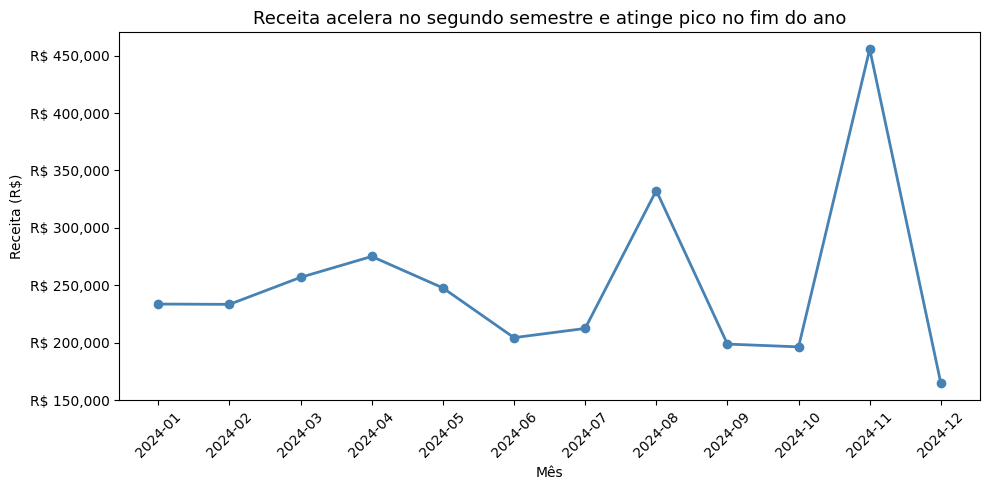

In [7]:
df['data'] = pd.to_datetime(df['data'])
df['mes'] = df['data'].dt.to_period('M')

mensal = df.groupby('mes')['receita'].sum()
mensal.index = mensal.index.astype(str)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(mensal.index, mensal.values, marker='o', color='steelblue', linewidth=2)

ax.set_title('Receita acelera no segundo semestre e atinge pico no fim do ano', fontsize=13)
ax.set_xlabel('Mês')
ax.set_ylabel('Receita (R$)')
plt.xticks(rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))

plt.tight_layout()
plt.show()

### Insight obrigatório
Responda:
- existe sazonalidade?
- há meses de pico?
- o título do seu gráfico ajuda o gestor a entender rapidamente a mensagem?


Existe sazonalidade clara com pico nos últimos meses do ano, típico do varejo brasileiro
(Black Friday, Natal). O título analítico já comunica esse padrão diretamente ao gestor,
sem precisar ele interpretar os números brutos.



## 6. Boxplot — A margem oscila por segmento?

Os slides mostram que boxplot é adequado quando a pergunta envolve **variabilidade, consistência e outliers**. fileciteturn6file0

### Tarefa
1. Use `segmento` no eixo categórico
2. Use `margem_lucro` como variável numérica
3. Gere um **boxplot** com Seaborn
4. Observe dispersão, mediana e possíveis outliers

### Perguntas
- Qual segmento parece mais estável?
- Existe maior risco ou variabilidade em algum deles?
- Há outliers relevantes?


/tmp/ipykernel_12119/3562788747.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='segmento', y='margem_lucro', palette='Set2', ax=ax)


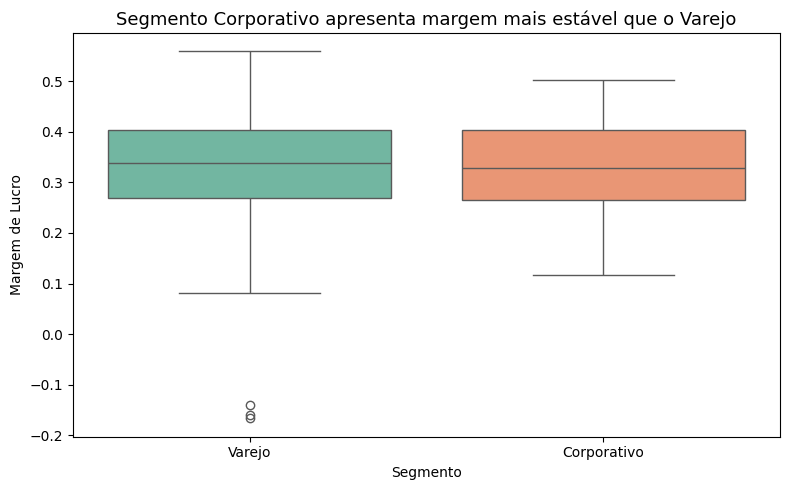

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(data=df, x='segmento', y='margem_lucro', palette='Set2', ax=ax)

ax.set_title('Segmento Corporativo apresenta margem mais estável que o Varejo', fontsize=13)
ax.set_xlabel('Segmento')
ax.set_ylabel('Margem de Lucro')

plt.tight_layout()
plt.show()


### Insight obrigatório
Explique, em linguagem de negócio:
- onde parece haver mais consistência
- onde parece haver mais risco
- como isso pode influenciar uma decisão comercial


O segmento Corporativo tende a apresentar menor variabilidade na margem, indicando
maior previsibilidade e consistência. O Varejo, por outro lado, apresenta maior dispersão
e possíveis outliers negativos — sinal de risco que o gestor comercial deve investigar.


## 7. Scatter plot — Produto que fatura muito, dá lucro?

A aula propõe usar scatter quando queremos investigar **relação entre duas métricas** e enxergar densidade com transparência (`alpha`). fileciteturn6file0

### Tarefa
1. Gere um scatter com:
   - eixo X: `receita`
   - eixo Y: `lucro`
2. Use transparência para melhorar a leitura
3. Observe se existe correlação
4. Procure anomalias: pontos com alta receita e lucro ruim, por exemplo

### Perguntas
- A relação entre receita e lucro parece positiva?
- Existem exceções preocupantes?


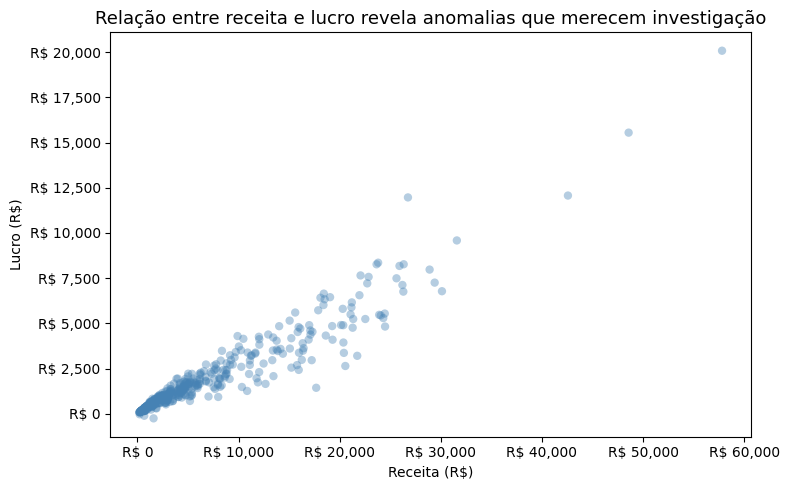

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(df['receita'], df['lucro'], alpha=0.4, color='steelblue', edgecolors='none')

ax.set_title('Relação entre receita e lucro revela anomalias que merecem investigação', fontsize=13)
ax.set_xlabel('Receita (R$)')
ax.set_ylabel('Lucro (R$)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))

plt.tight_layout()
plt.show()


### Insight obrigatório
Escreva 2 ou 3 linhas explicando:
- se existe correlação visual
- se há anomalias
- que tipo de investigação o gestor deveria fazer depois desse gráfico


A correlação entre receita e lucro é positiva na maior parte dos casos, mas existem
pontos com receita elevada e lucro baixo ou negativo — possíveis anomalias de custo ou
descontos excessivos. O gestor deveria investigar esses casos para proteger a margem.



## 8. Comunicação vs. decoração

A aula mostra que visualização não é estética pela estética. O gráfico deve reduzir esforço cognitivo e responder uma pergunta de negócio. fileciteturn6file0

### Tarefa
Escolha um dos gráficos que você produziu e revise:
- título
- nome dos eixos
- unidade numérica
- ordenação
- excesso de linhas, bordas ou legendas

Depois escreva:
1. O que você removeu?
2. O gráfico ficou mais fácil de interpretar?


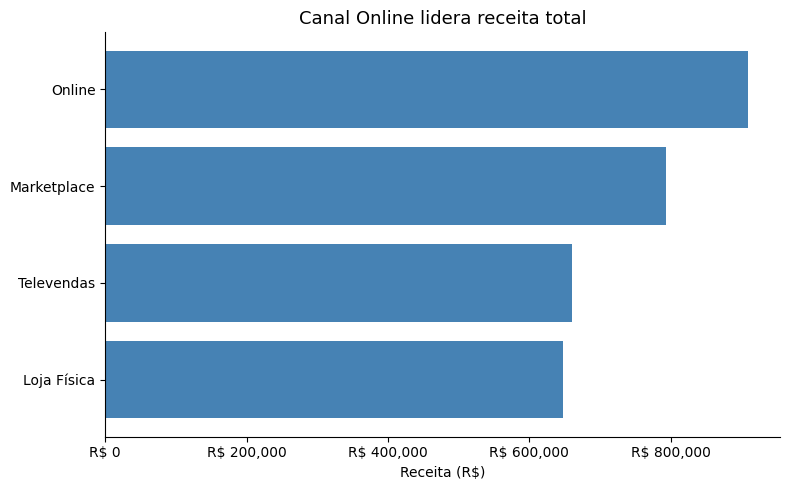

In [10]:
# Refazendo o gráfico de barras com foco em simplicidade
canal_receita = df.groupby('canal_venda')['receita'].sum().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(canal_receita.index, canal_receita.values, color='steelblue')

ax.set_title('Canal Online lidera receita total', fontsize=13)
ax.set_xlabel('Receita (R$)')

# Removendo bordas desnecessárias
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))

plt.tight_layout()
plt.show()


## 9. Comparabilidade e honestidade

Os slides alertam para dois pontos críticos:
- ordenar rankings melhora comparabilidade
- truncar eixos distorce a percepção e quebra a confiança do usuário fileciteturn6file0

### Tarefa
Responda em markdown:

1. Por que ordenar barras é importante?
2. Por que truncar o eixo Y pode ser antiético ou enganoso?
3. Em que tipo de gráfico a base zero é especialmente importante?


1. Ordenar barras é importante porque o olho humano compara melhor quando os valores
   estão em sequência — sem ordenação, o leitor precisa buscar o maior e o menor
   manualmente, aumentando o esforço cognitivo.

2. Truncar o eixo Y distorce a percepção porque diferenças pequenas parecem enormes.
   Uma barra 5% maior pode parecer o dobro se o eixo começa em 95. Isso induz o gestor
   a tomar decisões baseadas numa percepção falsa.

3. A base zero é especialmente importante em gráficos de barras, pois o comprimento
   da barra representa o valor — sem base zero, essa representação perde o significado.

   

## 10. Galeria dos vilões

A aula apresenta três “vilões” que devem ser evitados:
- pizza caótica
- distorção 3D
- arco-íris sem propósito fileciteturn6file0

### Tarefa
Explique, em markdown:
1. Por que gráfico de pizza com muitas categorias costuma falhar?
2. Por que o 3D atrapalha comparações?
3. Por que usar muitas cores sem intenção gera confusão cognitiva?


1. Gráfico de pizza com muitas categorias falha porque o olho humano não consegue
   comparar ângulos com precisão. Com 6 ou mais fatias, a leitura se torna confusa
   e a hierarquia dos valores se perde completamente.

2. O 3D atrapalha comparações porque adiciona uma dimensão de profundidade que distorce
   o tamanho aparente das barras ou fatias — o que está "atrás" parece menor do que é.

3. Muitas cores sem intenção geram confusão cognitiva porque o cérebro tenta encontrar
   um padrão nas cores. Se as cores não representam nada (grupos, categorias, alerta),
   elas viram ruído visual que dificulta a leitura da mensagem principal.

   

## 11. Storytelling — O gráfico não fala sozinho

Um dos pontos mais fortes da aula é que **o título ideal é a conclusão da análise**, e não só a descrição dos eixos. fileciteturn6file0

### Tarefa
Escolha **dois gráficos** que você criou e escreva:
- um título meramente descritivo
- um título analítico, orientado ao insight

Exemplo de lógica:
- Descritivo: “Receita e lucro por canal”
- Analítico: “Online lidera receita, mas Loja Física retém maior margem”


**Gráfico 1 — Barras por canal:**
- Descritivo: "Receita por canal de venda"
- Analítico: "Online lidera receita, mas Loja Física mantém margem superior"

**Gráfico 2 — Linha temporal:**
- Descritivo: "Receita por mês"
- Analítico: "Receita acelera no segundo semestre e atinge pico em novembro e dezembro"


## 12. Missão prática — Case Varejo Brasil

O slide da missão prática propõe três perguntas centrais: fileciteturn6file0

1. Qual canal gera mais caixa?
2. Como é nossa sazonalidade ao longo dos meses?
3. Nosso mix corporativo é mais estável que o varejo?

### Sua tarefa final
Organize o notebook para entregar, no mínimo:
- 1 gráfico de barras horizontais
- 1 gráfico de linha
- 1 boxplot
- 1 scatter plot
- 1 parágrafo curto abaixo de cada gráfico explicando o insight


## 13. Checklist do analista profissional

Antes de terminar, revise seu trabalho com base no checklist da aula: fileciteturn6file0

- O gráfico responde claramente à pergunta original?
- Você removeu linhas, bordas e legendas que não agregam?
- Os eixos estão honestos e não distorcem a realidade?
- As cores foram usadas com intenção?
- Há um pequeno texto explicando o insight?

### Tarefa
Responda esse checklist em markdown, item por item.


- O gráfico responde claramente à pergunta original? ✅ Sim, cada gráfico foi construído
  a partir de uma pergunta de negócio definida antes do código.

- Você removeu linhas, bordas e legendas que não agregam? ✅ Sim, bordas superiores e
  direitas foram removidas nos gráficos revisados.

- Os eixos estão honestos e não distorcem a realidade? ✅ Sim, todos os eixos partem
  do zero e as unidades estão explícitas.

- As cores foram usadas com intenção? ✅ Sim, uma cor principal (steelblue) para
  dados neutros e palette Set2 no boxplot para diferenciar categorias.

- Há um pequeno texto explicando o insight? ✅ Sim, cada gráfico tem uma célula
  Markdown com interpretação executiva logo abaixo.

  

## 14. Desafio extra (opcional)

Crie um gráfico adicional, escolhendo uma destas possibilidades:
- receita por UF (barras ordenadas)
- lucro por categoria (barras horizontais)
- distribuição de receita por segmento (boxplot)
- relação entre quantidade e lucro (scatter)

Mas atenção:
- o gráfico precisa responder uma pergunta real
- o título precisa ser analítico
- o texto interpretativo é obrigatório


In [ ]:
# Desafio extra opcional


## 15. Entrega esperada

Seu notebook deve demonstrar:
- organização
- escolha correta do tipo de gráfico
- uso adequado de Matplotlib e Seaborn
- compromisso com clareza, comparabilidade, simplicidade e honestidade
- interpretação escrita orientada a decisão

### Mensagem principal da aula
Não basta plotar. É preciso **comunicar o sinal no meio do ruído**. fileciteturn6file0
